# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [11]:
# Capstone — Section 1: Research Question

research_question = (
    "Which web pages should be prioritized for SEO optimization "
    "based on observed CTR and average search position?"
)

decision_supported = (
    "The analysis supports a directional decision about which pages "
    "should receive SEO review first. It does not guarantee future "
    "traffic, rankings, or clicks."
)

print("Research Question:")
print(research_question)

print("\nDecision Supported:")
print(decision_supported)

Research Question:
Which web pages should be prioritized for SEO optimization based on observed CTR and average search position?

Decision Supported:
The analysis supports a directional decision about which pages should receive SEO review first. It does not guarantee future traffic, rankings, or clicks.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [12]:
# Capstone — Section 2: Restore repository and load data

import os
import pandas as pd

repo_path = "/content/flyrank-ml-internship"

# Clone the repository if needed
if not os.path.exists(repo_path):
    print("Repository not found. Cloning...")
    !git clone -q https://github.com/umm319/flyrank-ml-internship.git /content/flyrank-ml-internship
else:
    print("Repository already exists.")

# Find the dataset
data_path = None

for root, dirs, files in os.walk(repo_path):
    if "content_refresh_anonymized.csv" in files:
        data_path = os.path.join(root, "content_refresh_anonymized.csv")
        break

print("Dataset path:", data_path)

if data_path is None:
    raise FileNotFoundError(
        "content_refresh_anonymized.csv was not found in the repository."
    )

# Load dataset
df = pd.read_csv(data_path)

print("\n✅ Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

print("\nData release: content_refresh_anonymized.csv")
print("Available windows: 90-day and 30-day aggregate performance fields.")

print("\nExcluded from analysis:")
print("- Client names")
print("- Private search queries")
print("- Personally identifying information")

Repository already exists.
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

✅ Dataset loaded successfully!
Dataset shape: (30000, 44)
Number of columns: 44

Data release: content_refresh_anonymized.csv
Available windows: 90-day and 30-day aggregate performance fields.

Excluded from analysis:
- Client names
- Private search queries
- Personally identifying information


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [13]:
# Capstone — Section 3: Methodology

import numpy as np
import pandas as pd

# Required signals
df["ctr"] = pd.to_numeric(df["ctr"], errors="coerce")
df["avg_position"] = pd.to_numeric(df["avg_position"], errors="coerce")

# In this dataset, avg_position = 0 means no usable position data
valid_position = df["avg_position"].replace(0, np.nan)

# Baseline thresholds
ctr_threshold = df["ctr"].median()
position_threshold = valid_position.median()

# Features used by the baseline
features_used = [
    "ctr",
    "avg_position"
]

# Baseline rule
df["baseline_reason_code"] = np.where(
    (df["ctr"] < ctr_threshold) &
    (valid_position > position_threshold),
    "CTR_LOW_POSITION",
    "MONITOR"
)

# Baseline action
df["baseline_action"] = np.where(
    df["baseline_reason_code"] == "CTR_LOW_POSITION",
    "Prioritize Optimization",
    "Monitor"
)

print("Methodology")
print("-----------")
print("Unit of analysis: web page")
print("Features used:", features_used)
print("CTR threshold:", ctr_threshold)
print("Position threshold:", position_threshold)
print("Baseline rule: low CTR AND poor average position")
print("Reason code: CTR_LOW_POSITION")

print("\nLeakage check:")
print("- No target-derived feature used.")
print("- No future-window feature used.")
print("- avg_position = 0 treated as missing.")
print("✅ Baseline methodology defined.")

Methodology
-----------
Unit of analysis: web page
Features used: ['ctr', 'avg_position']
CTR threshold: 0.07
Position threshold: 11.4
Baseline rule: low CTR AND poor average position
Reason code: CTR_LOW_POSITION

Leakage check:
- No target-derived feature used.
- No future-window feature used.
- avg_position = 0 treated as missing.
✅ Baseline methodology defined.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [14]:
# Capstone — Section 4: Results vs Baseline

# Number of pages
total_pages = len(df)

# Pages selected by the baseline rule
prioritized_pages = (
    df["baseline_reason_code"] == "CTR_LOW_POSITION"
).sum()

# Percentage prioritized
priority_rate = (
    prioritized_pages / total_pages * 100
)

# Baseline score summary
baseline_summary = pd.DataFrame({
    "Metric": [
        "Total pages",
        "Pages prioritized",
        "Pages monitored",
        "Priority rate (%)"
    ],
    "Baseline": [
        total_pages,
        prioritized_pages,
        total_pages - prioritized_pages,
        round(priority_rate, 2)
    ]
})

display(baseline_summary)

print("\nResults interpretation:")
print(
    f"The baseline prioritized {prioritized_pages:,} of "
    f"{total_pages:,} pages ({priority_rate:.2f}%)."
)

print(
    "This is a directional prioritization result. "
    "It should be reviewed against page context before implementation."
)

print(
    "\nNo model-vs-baseline performance claim is made here because "
    "no independently evaluated model result was used in this section."
)

,Metric,Baseline
0,Total pages,30000.00
1,Pages prioritized,7863.00
2,Pages monitored,22137.00
3,Priority rate (%),26.21



Results interpretation:
The baseline prioritized 7,863 of 30,000 pages (26.21%).
This is a directional prioritization result. It should be reviewed against page context before implementation.

No model-vs-baseline performance claim is made here because no independently evaluated model result was used in this section.


## 5. Limitations

*What this work cannot claim.*

In [15]:
# Capstone — Section 5: Limitations

limitations = [
    "The baseline identifies pages for review; it does not guarantee higher CTR, rankings, or traffic.",
    "CTR can be affected by search intent, SERP features, seasonality, and other factors not captured by the rule.",
    "Average position is an observed signal and does not establish that poor position caused low CTR.",
    "The analysis uses anonymized aggregate data and does not include private search queries or client names.",
    "Pages with missing or unusable position data are not treated as evidence of poor ranking.",
    "The results are directional decision-support and should be validated with page-level context before implementation."
]

print("Limitations")
print("-----------")

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print("\n✅ Limitations documented.")

Limitations
-----------
1. The baseline identifies pages for review; it does not guarantee higher CTR, rankings, or traffic.
2. CTR can be affected by search intent, SERP features, seasonality, and other factors not captured by the rule.
3. Average position is an observed signal and does not establish that poor position caused low CTR.
4. The analysis uses anonymized aggregate data and does not include private search queries or client names.
5. Pages with missing or unusable position data are not treated as evidence of poor ranking.
6. The results are directional decision-support and should be validated with page-level context before implementation.

✅ Limitations documented.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:
# Capstone — Section 6: Ranked Recommendations

import os
import numpy as np
import pandas as pd

# Make sure the required columns are numeric
df["ctr"] = pd.to_numeric(df["ctr"], errors="coerce")
df["avg_position"] = pd.to_numeric(df["avg_position"], errors="coerce")

# Treat avg_position = 0 as missing position data
valid_position = df["avg_position"].replace(0, np.nan)

# Use the same thresholds as the baseline
ctr_threshold = df["ctr"].median()
position_threshold = valid_position.median()

# Select pages matching the baseline rule
ranked_recommendations = df[
    (df["ctr"] < ctr_threshold) &
    (valid_position > position_threshold)
].copy()

# Calculate priority score
ctr_gap = (
    (ctr_threshold - ranked_recommendations["ctr"]) /
    (abs(ctr_threshold) + 1e-9)
)

position_gap = (
    (ranked_recommendations["avg_position"] - position_threshold) /
    (abs(position_threshold) + 1e-9)
)

ranked_recommendations["priority_score"] = (
    ctr_gap.fillna(0) + position_gap.fillna(0)
)

# Rank highest priority first
ranked_recommendations = ranked_recommendations.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

ranked_recommendations["priority_rank"] = (
    ranked_recommendations.index + 1
)

# Reason code
ranked_recommendations["baseline_reason_code"] = (
    "CTR_LOW_POSITION"
)

# Recommended action
ranked_recommendations["recommended_action"] = (
    "Review title, search intent, and on-page content before optimization"
)

# Keep useful columns
recommendation_columns = [
    "priority_rank",
    "content_id",
    "ctr",
    "avg_position",
    "priority_score",
    "baseline_reason_code",
    "recommended_action"
]

ranked_recommendations = ranked_recommendations[
    recommendation_columns
]

# Display Top 20
print("Ranked recommendations created successfully!")
display(ranked_recommendations.head(20))

# Create output folder
output_dir = "/content/flyrank-ml-internship/work/outputs"
os.makedirs(output_dir, exist_ok=True)

# Save recommendations
recommendation_path = os.path.join(
    output_dir,
    "capstone_ranked_recommendations.csv"
)

ranked_recommendations.to_csv(
    recommendation_path,
    index=False
)

print("\n✅ Recommendations saved successfully!")
print("File:", recommendation_path)
print("Total recommendations:", len(ranked_recommendations))

Ranked recommendations created successfully!


,priority_rank,content_id,ctr,avg_position,priority_score,baseline_reason_code,recommended_action
0,1,content_661e1745db72,0.0,245.0,21.491228,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
1,2,content_23f1cc8851a9,0.0,184.0,16.140351,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
2,3,content_7275a6a3a8eb,0.0,165.5,14.517544,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
3,4,content_71a31b831092,0.0,161.0,14.122807,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
4,5,content_42c7c72b8391,0.0,145.5,12.763158,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
5,6,content_cb6c7d58c0bc,0.0,144.5,12.675439,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
6,7,content_692fda8c52bd,0.0,142.0,12.456140,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
7,8,content_3e087a5d8f15,0.0,138.8,12.175439,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
8,9,content_13bbd72aea33,0.0,118.0,10.350877,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."
9,10,content_abeb1aa40158,0.0,113.5,9.956140,CTR_LOW_POSITION,"Review title, search intent, and on-page conte..."



✅ Recommendations saved successfully!
File: /content/flyrank-ml-internship/work/outputs/capstone_ranked_recommendations.csv
Total recommendations: 7863


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

✅ Top-20 table saved:
/content/flyrank-ml-internship/work/outputs/capstone_top20_recommendations.csv

✅ Baseline summary saved:
/content/flyrank-ml-internship/work/outputs/capstone_baseline_summary.csv


,Metric,Value
0,Total pages,30000.00
1,Prioritized pages,7863.00
2,Monitored pages,22137.00
3,Priority rate (%),26.21


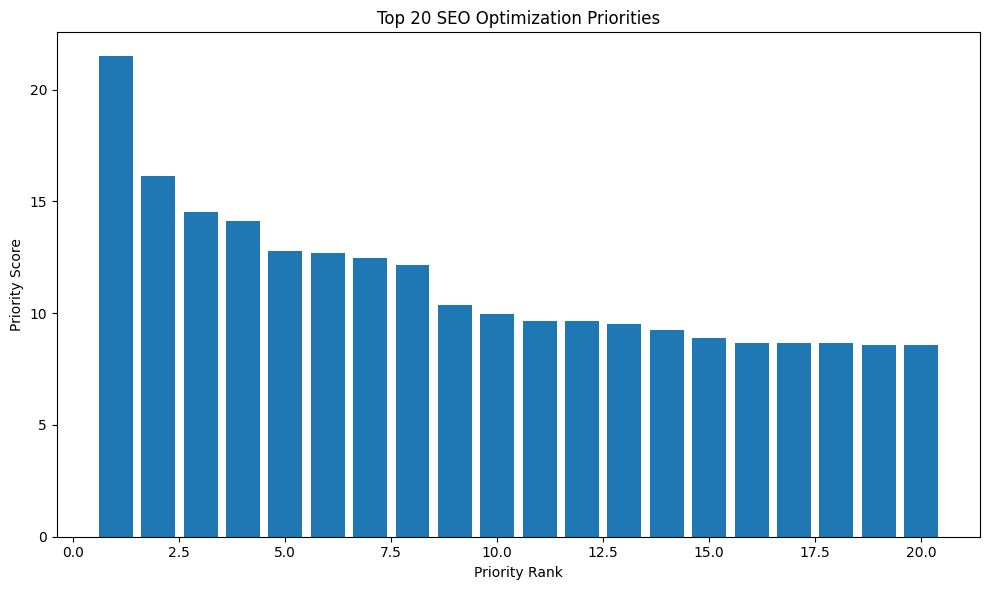


✅ Chart saved:
/content/flyrank-ml-internship/work/outputs/capstone_top20_priority_scores.png

Artifacts generated successfully:
1. /content/flyrank-ml-internship/work/outputs/capstone_top20_recommendations.csv
2. /content/flyrank-ml-internship/work/outputs/capstone_baseline_summary.csv
3. /content/flyrank-ml-internship/work/outputs/capstone_top20_priority_scores.png


In [17]:
# Capstone — Section 7: Artifacts

import os
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Create output directory
# --------------------------------------------------

output_dir = "/content/flyrank-ml-internship/work/outputs"
os.makedirs(output_dir, exist_ok=True)

# --------------------------------------------------
# 2. Create Top-20 recommendation table
# --------------------------------------------------

top20_artifact = ranked_recommendations.head(20).copy()

top20_path = os.path.join(
    output_dir,
    "capstone_top20_recommendations.csv"
)

top20_artifact.to_csv(
    top20_path,
    index=False
)

print("✅ Top-20 table saved:")
print(top20_path)

# --------------------------------------------------
# 3. Create baseline summary table
# --------------------------------------------------

total_pages = len(df)

prioritized_pages = (
    (df["ctr"] < ctr_threshold) &
    (valid_position > position_threshold)
).sum()

monitored_pages = total_pages - prioritized_pages

priority_rate = (
    prioritized_pages / total_pages * 100
)

summary = pd.DataFrame({
    "Metric": [
        "Total pages",
        "Prioritized pages",
        "Monitored pages",
        "Priority rate (%)"
    ],
    "Value": [
        total_pages,
        prioritized_pages,
        monitored_pages,
        round(priority_rate, 2)
    ]
})

summary_path = os.path.join(
    output_dir,
    "capstone_baseline_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print("\n✅ Baseline summary saved:")
print(summary_path)

display(summary)

# --------------------------------------------------
# 4. Create priority score chart
# --------------------------------------------------

chart_data = ranked_recommendations.head(20)

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(chart_data) + 1),
    chart_data["priority_score"]
)

plt.xlabel("Priority Rank")
plt.ylabel("Priority Score")
plt.title("Top 20 SEO Optimization Priorities")
plt.tight_layout()

chart_path = os.path.join(
    output_dir,
    "capstone_top20_priority_scores.png"
)

plt.savefig(
    chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Chart saved:")
print(chart_path)

# --------------------------------------------------
# 5. Artifact summary
# --------------------------------------------------

print("\nArtifacts generated successfully:")
print("1.", top20_path)
print("2.", summary_path)
print("3.", chart_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.